# DA25M502 IDL Assignment 3 Submissions Coding
- Name : Amardeep Kumar
- Roll No : DA25M502

In [4]:
!pip install wandb

In [5]:
%%writefile wandb_utils.py
import wandb
class WandBLogger:
    def __init__(self, project, config):
        self.wandb = wandb
        self.run = wandb.init(project=project, config=config)

    def watch(self, model):
        self.wandb.watch(model, log="all")

    def log(self, data):
        self.wandb.log(data)

    def finish(self):
        self.wandb.finish()

Overwriting wandb_utils.py


In [6]:
from google.colab import userdata
import wandb
wandb.login(key=userdata.get("WANDB_API_KEY"))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kumaramardeep342 (kumaramardeep342-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

## Question 1 : Explore what causes slow training in multilayer perceptron neural networks even in the absence of vanishing gradients (a statistical view).
----

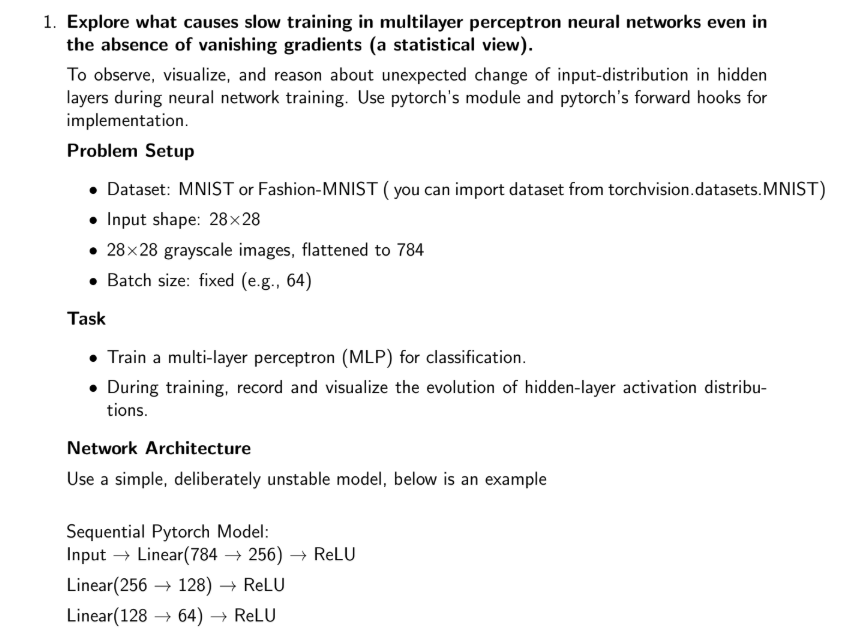

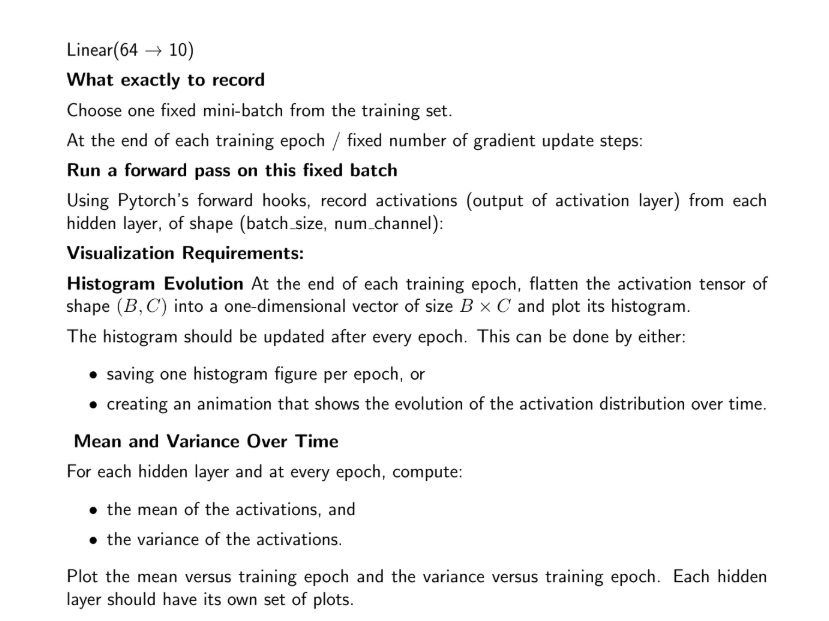

Epoch 1
layer_0: mean=0.1876, var=0.0565


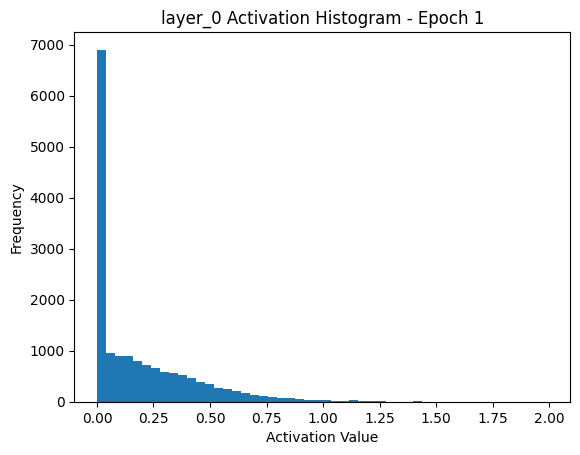

layer_1: mean=0.2021, var=0.0530


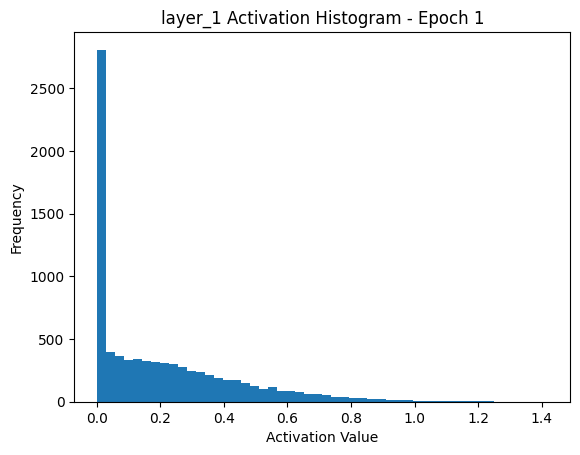

layer_2: mean=0.1724, var=0.0550


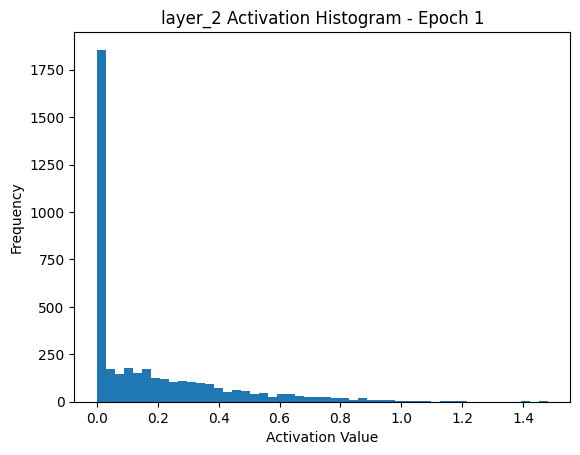

Epoch 2
layer_0: mean=0.4213, var=0.2032


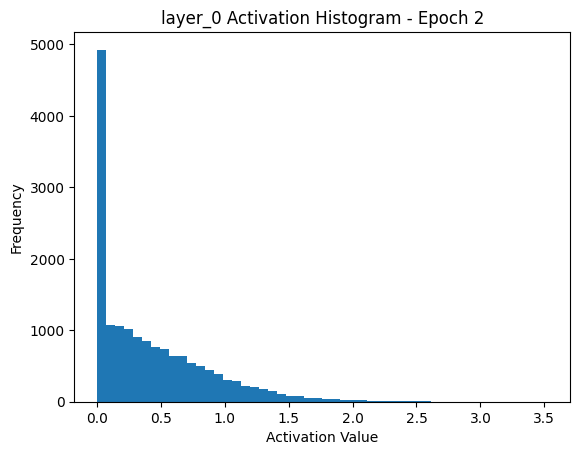

layer_1: mean=0.8134, var=0.6422


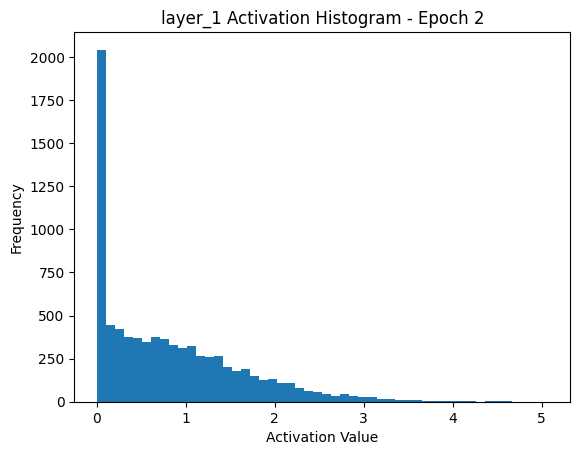

layer_2: mean=1.2399, var=1.9740


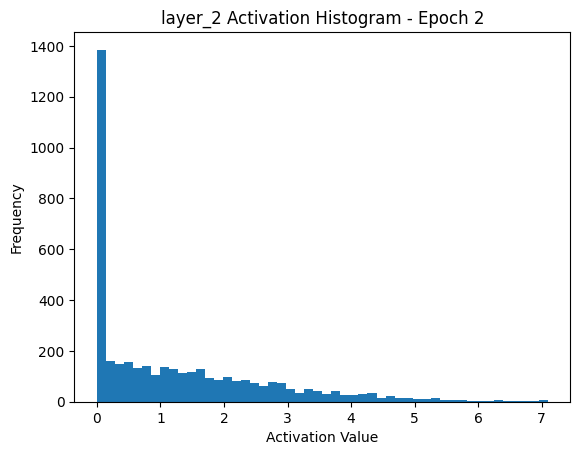

Epoch 3
layer_0: mean=0.4561, var=0.2272


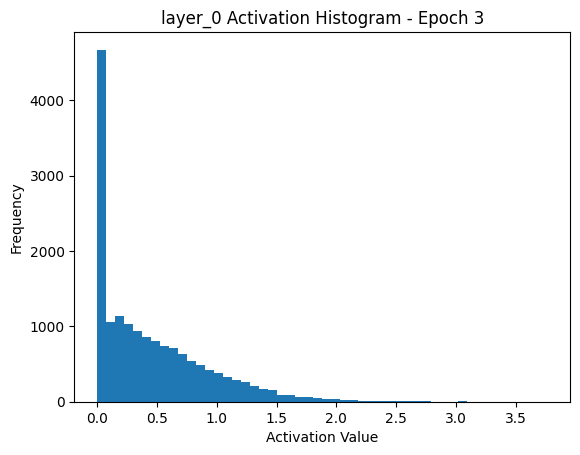

layer_1: mean=0.9314, var=0.8071


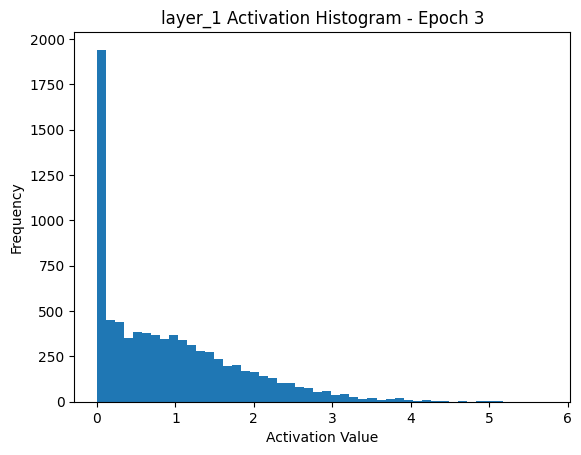

layer_2: mean=1.4974, var=2.7391


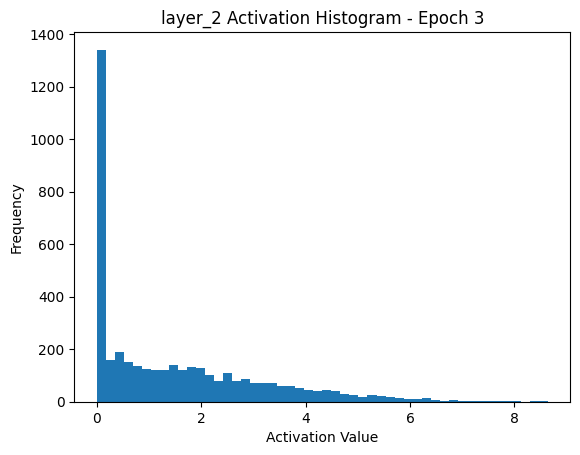

Epoch 4
layer_0: mean=0.4500, var=0.2268


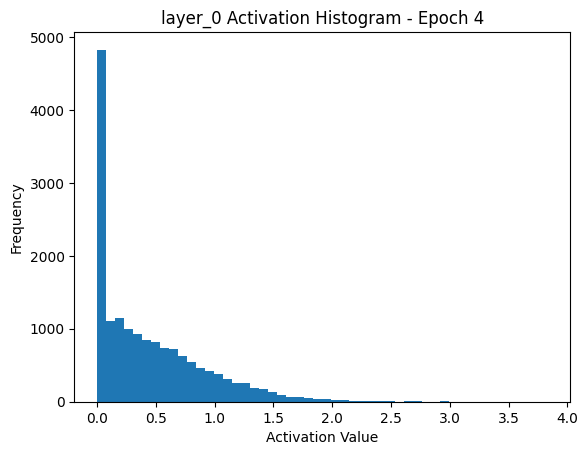

layer_1: mean=0.9364, var=0.8125


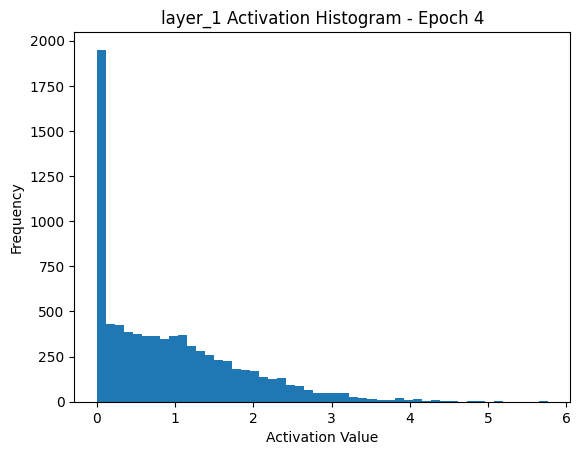

layer_2: mean=1.5178, var=2.8660


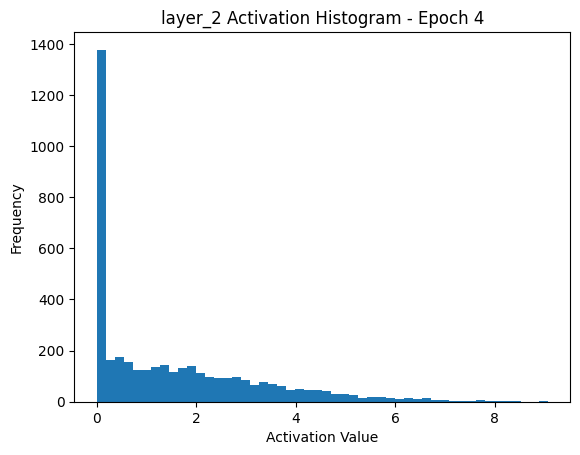

Epoch 5
layer_0: mean=0.4358, var=0.2203


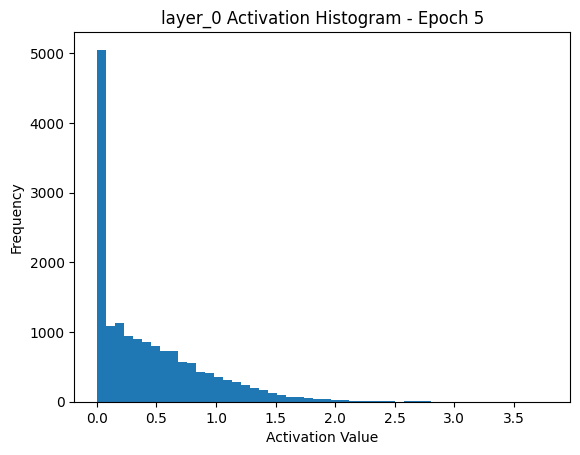

layer_1: mean=0.9044, var=0.7819


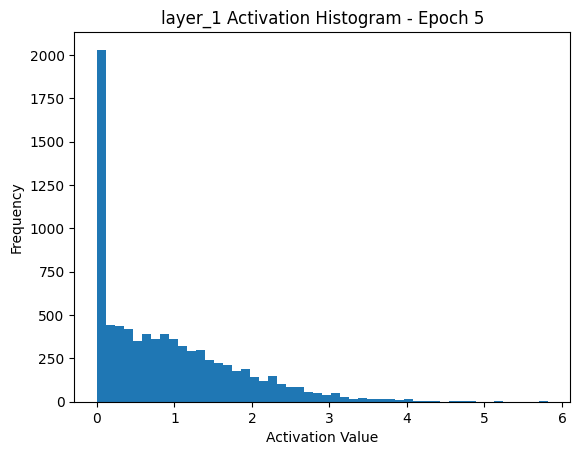

layer_2: mean=1.4804, var=2.7813


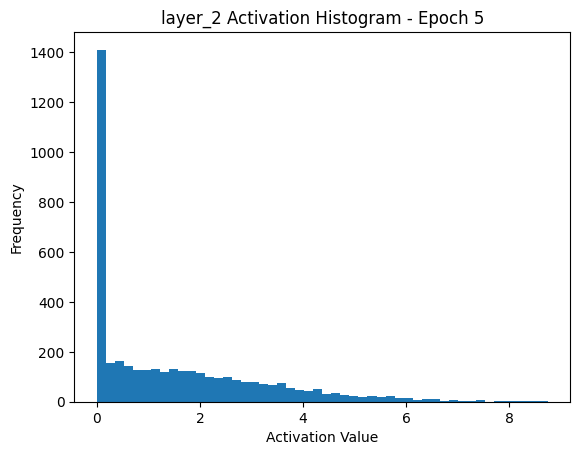

Epoch 6
layer_0: mean=0.4229, var=0.2151


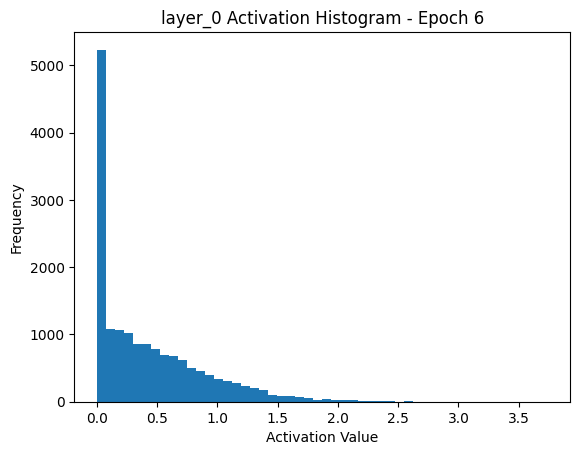

layer_1: mean=0.8793, var=0.7559


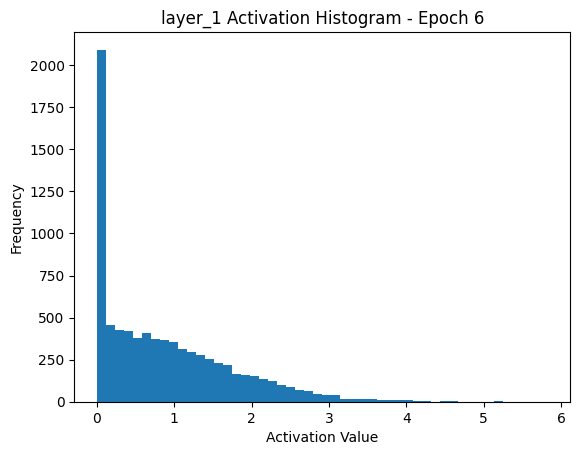

layer_2: mean=1.4620, var=2.7237


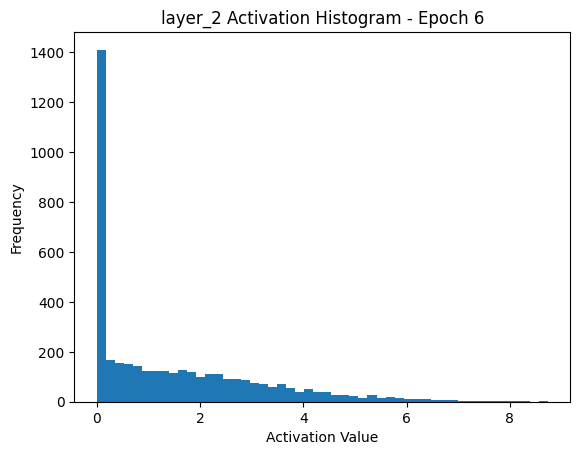

Epoch 7
layer_0: mean=0.4106, var=0.2090


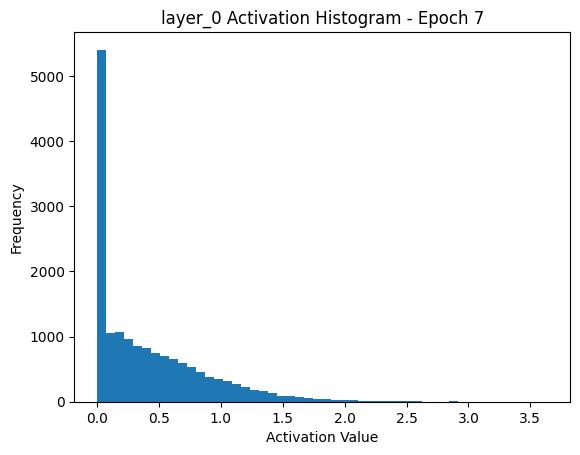

layer_1: mean=0.8539, var=0.7254


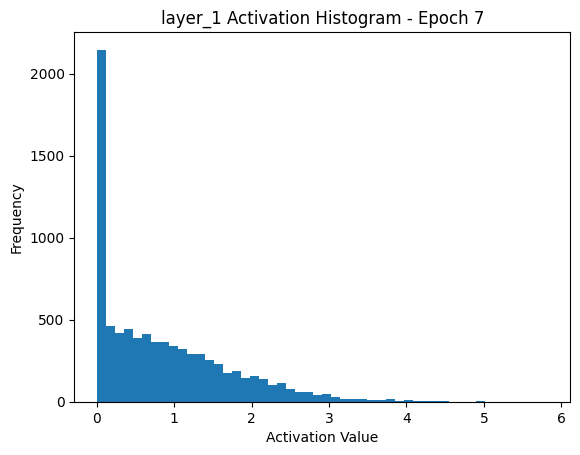

layer_2: mean=1.4415, var=2.6630


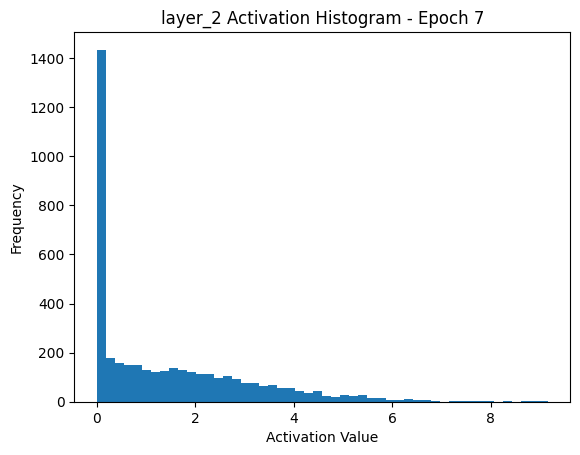

Epoch 8
layer_0: mean=0.4008, var=0.2035


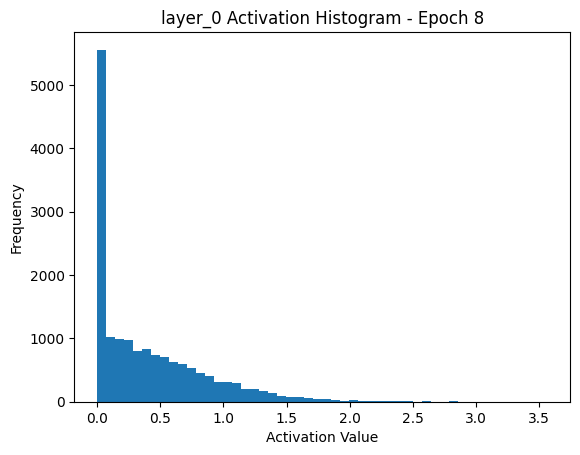

layer_1: mean=0.8305, var=0.6942


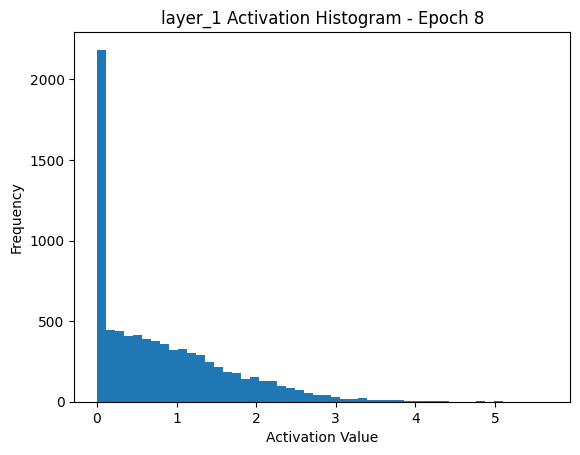

layer_2: mean=1.4138, var=2.5859


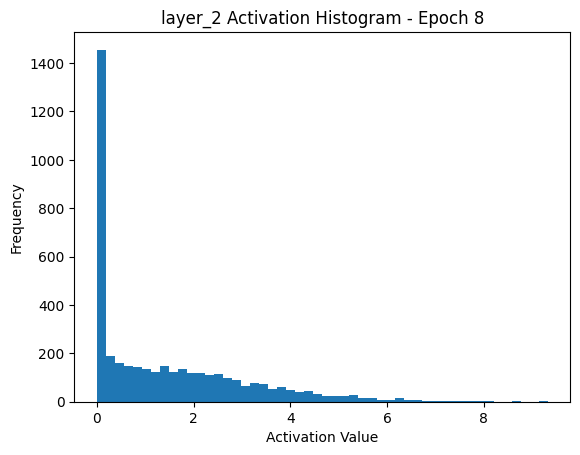

Epoch 9
layer_0: mean=0.3930, var=0.2004


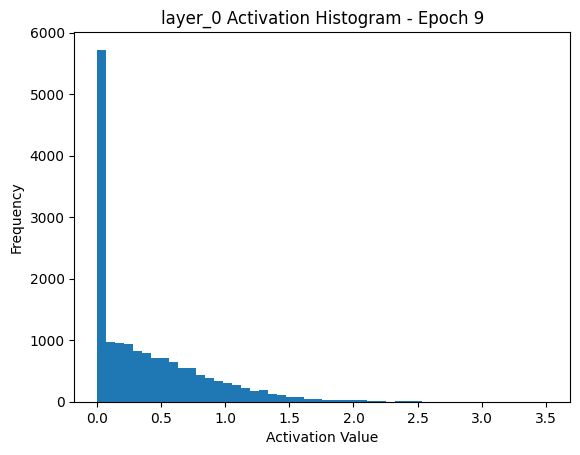

layer_1: mean=0.8207, var=0.6690


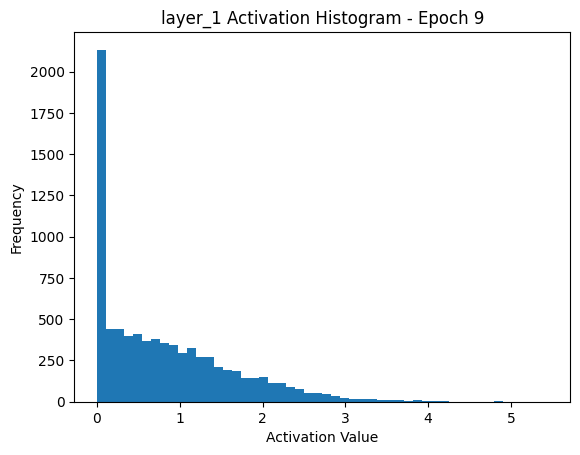

layer_2: mean=1.4129, var=2.5627


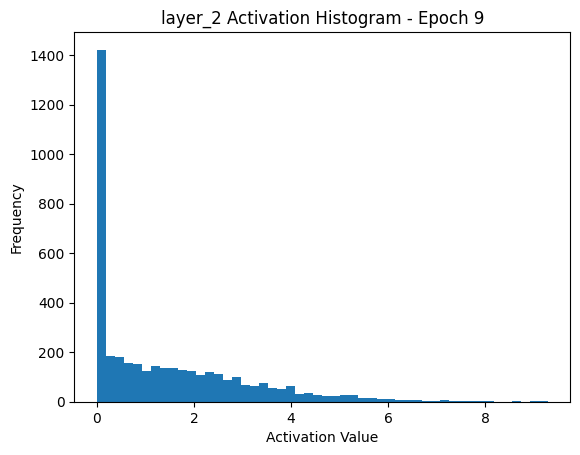

Epoch 10
layer_0: mean=0.3873, var=0.1983


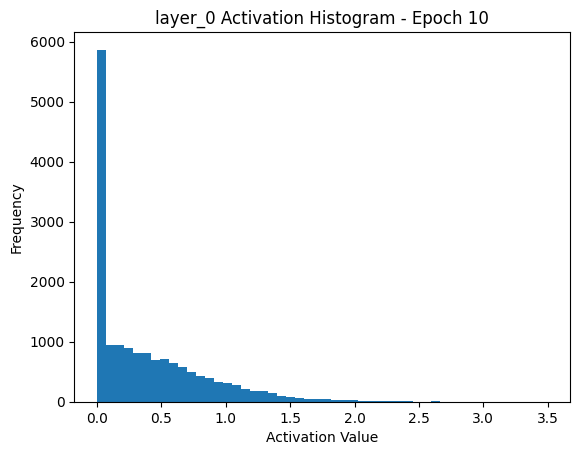

layer_1: mean=0.8145, var=0.6470


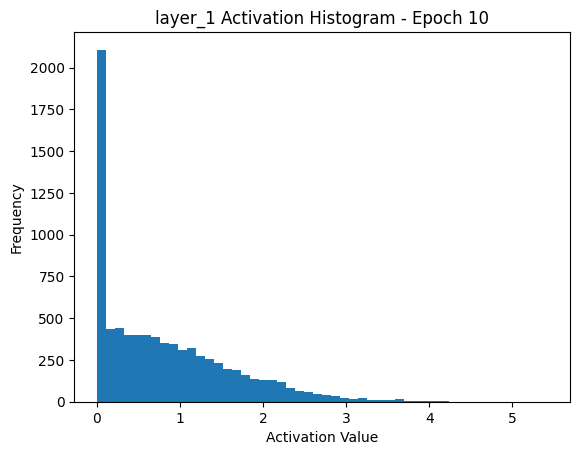

layer_2: mean=1.4118, var=2.5301


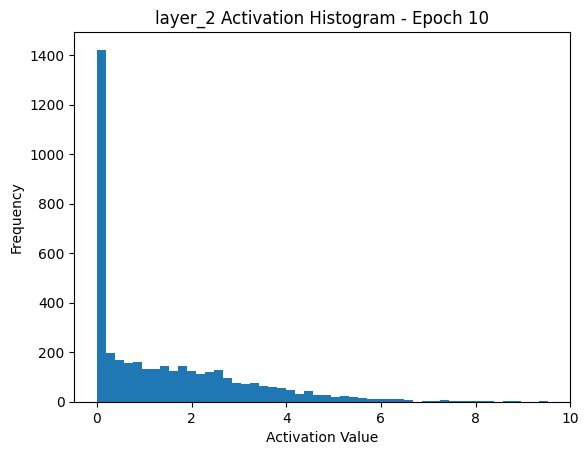

layer_0_mean,▁▇██▇▇▇▇▆▆
layer_0_var,▁▇████▇▇▇▇
layer_1_mean,▁▇███▇▇▇▇▇
layer_1_var,▁▆███▇▇▇▇▆
layer_2_mean,▁▇█████▇▇▇
layer_2_var,▁▆████▇▇▇▇
layer_0_mean,0.38725
layer_0_var,0.19828
layer_1_mean,0.81451
layer_1_var,0.64696
layer_2_mean,1.4118


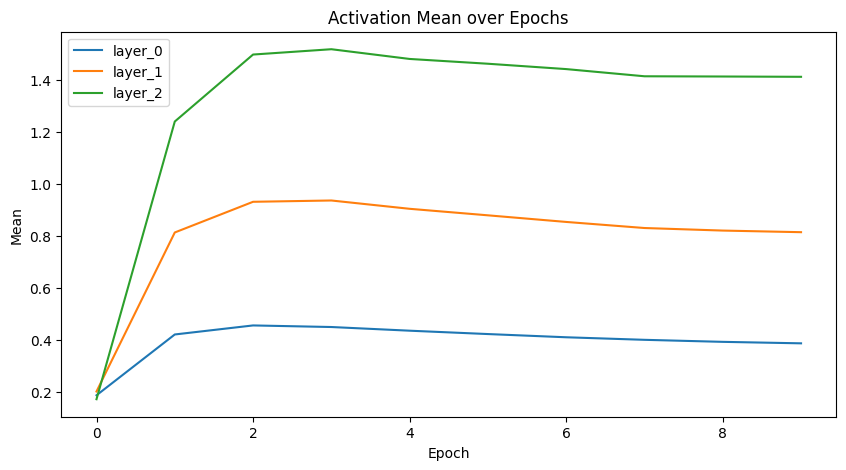

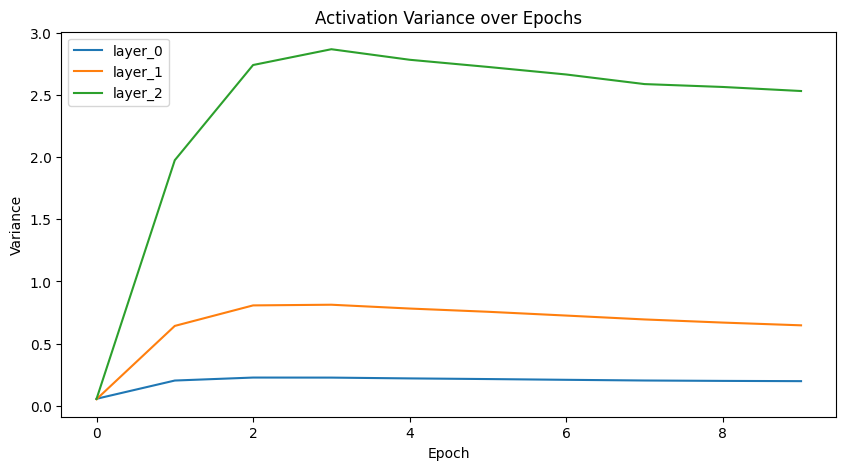

In [9]:

#==============================================
# 1. Load dataset
#==============================================
batch_size = 64
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 → 784
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

#====================================================
# 2. Define MLP Layer
#====================================================
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(784,256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.layers(x)

model = MLP()

#==============================================
#       wandb intilization
#==============================================
from wandb_utils import WandBLogger
logger = WandBLogger(
    project="Predictive Maintenance",
    config={
        "epochs": 10,
        "batch_size": 64,
        "lr": 0.01,
        "architecture": "MLP"
    }
)
logger.watch(model)

#==============================================
# 3.Loass + Optimizer + Fixed Batch
#==============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

fixed_batch, fixed_labels = next(iter(train_loader))
#=============================================
# 4. Hooks
#=============================================
activations = {}
def get_hook(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

layer_idx = 0
for layer in model.layers:
    if isinstance(layer, nn.ReLU):
        layer.register_forward_hook(get_hook(f"layer_{layer_idx}"))
        layer_idx += 1

#=====================================================
# 5. Model Training
#=====================================================
num_epochs = 10
mean_history = {f"layer_{i}": [] for i in range(3)}
var_history = {f"layer_{i}": [] for i in range(3)}


for epoch in range(num_epochs):

    # train
    model.train()
    for x, y in train_loader:
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    # evaluate on fixed batch
    model.eval()
    _ = model(fixed_batch)  # triggers hooks

    print(f"Epoch {epoch+1}")
    log_dict = {}
    for key in activations:
        act = activations[key].cpu().numpy().flatten()

        mean = np.mean(act)
        var = np.var(act)

        mean_history[key].append(mean)
        var_history[key].append(var)

        print(f"{key}: mean={mean:.4f}, var={var:.4f}")

        # Histogram
        plt.figure()
        plt.hist(act, bins=50)
        plt.title(f"{key} Activation Histogram - Epoch {epoch+1}")
        plt.xlabel("Activation Value")
        plt.ylabel("Frequency")
        plt.show()

        # 🔥 WandB logging
        log_dict[f"{key}_mean"] = mean
        log_dict[f"{key}_var"] = var
        log_dict[f"{key}_hist"] = wandb.Histogram(act)
    # ✅ send everything to WandB
    logger.log(log_dict)
logger.finish()
#===============================================================
# Mean + Variance
#===============================================================
# Mean Plot
plt.figure(figsize=(10,5))
for key in mean_history:
    plt.plot(mean_history[key], label=key)

plt.title("Activation Mean over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean")
plt.legend()
plt.show()


# Variance Plot
plt.figure(figsize=(10,5))
for key in var_history:
    plt.plot(var_history[key], label=key)

plt.title("Activation Variance over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Variance")
plt.legend()
plt.tight_layout
plt.show()


## Question 4 : Implement the Adam optimizer from scratch and compare it with vanilla Stochastic Gradient Descent (SGD) on a non-convex optimization problem.
---


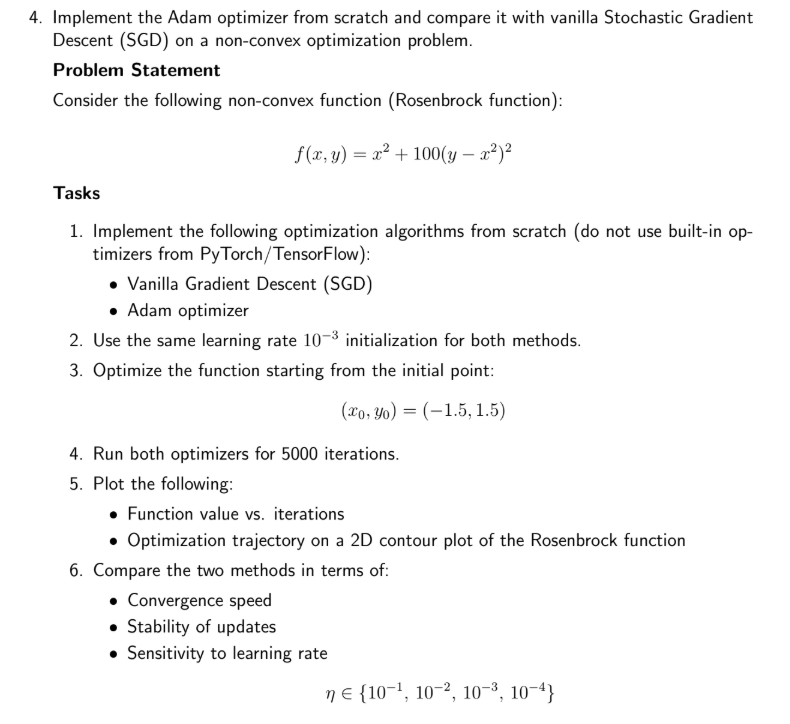

/tmp/ipykernel_1749/1121763839.py:6: RuntimeWarning: overflow encountered in scalar power
  return x**2 + 100*(y-x**2)**2
/tmp/ipykernel_1749/1121763839.py:9: RuntimeWarning: overflow encountered in scalar power
  df_dx = 2*x -4*100*x*(y-x**2)
/tmp/ipykernel_1749/1121763839.py:10: RuntimeWarning: overflow encountered in scalar power
  df_dy = 200*(y-x**2)
/tmp/ipykernel_1749/1121763839.py:6: RuntimeWarning: invalid value encountered in scalar subtract
  return x**2 + 100*(y-x**2)**2
/tmp/ipykernel_1749/1121763839.py:9: RuntimeWarning: invalid value encountered in scalar subtract
  df_dx = 2*x -4*100*x*(y-x**2)
/tmp/ipykernel_1749/1121763839.py:10: RuntimeWarning: invalid value encountered in scalar subtract
  df_dy = 200*(y-x**2)


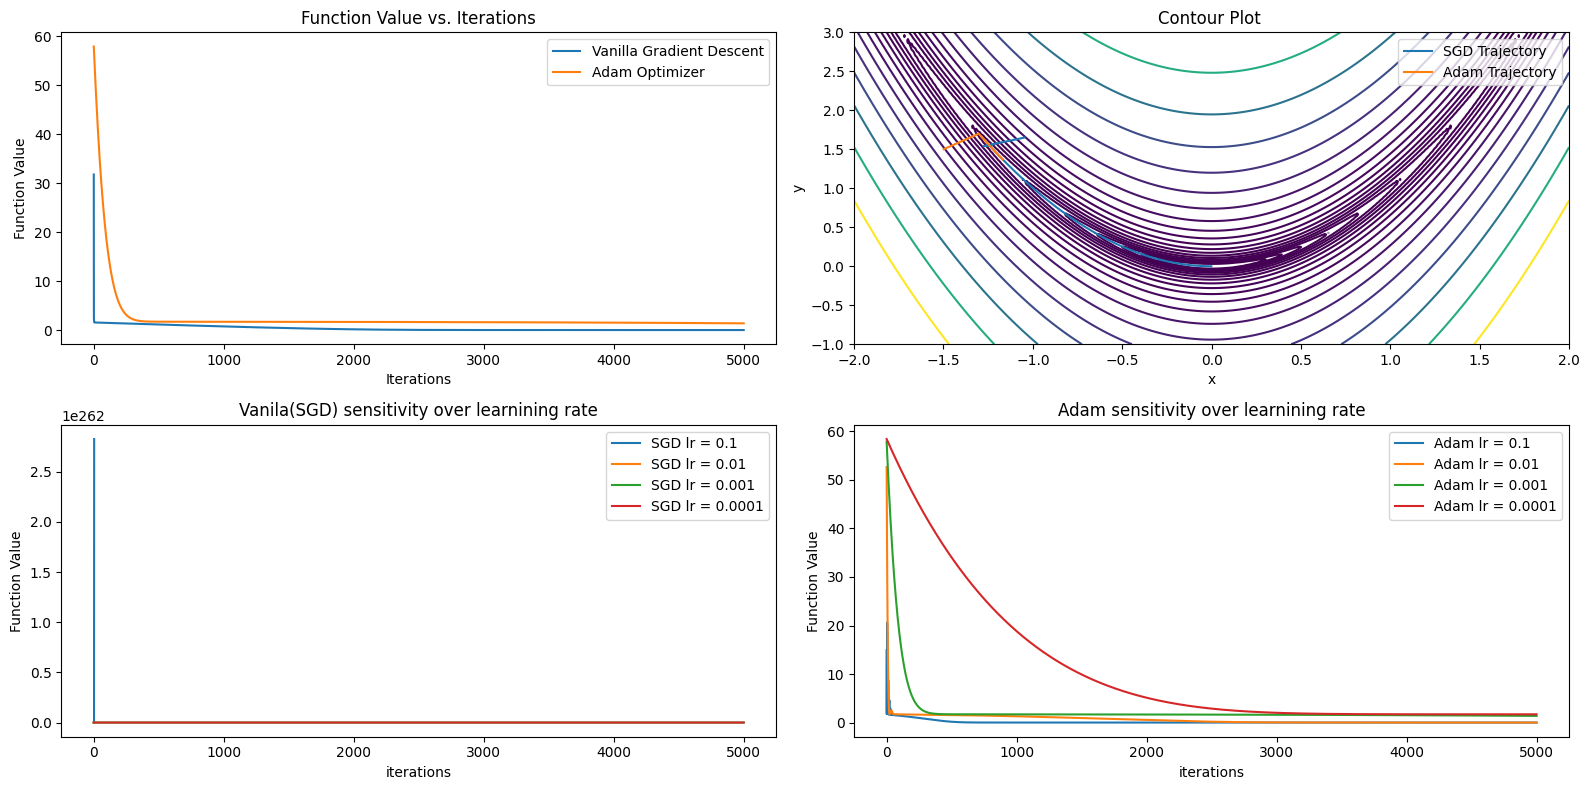

In [ ]:
#==============================================
# 1.Rosenbrock function and graident
#==============================================

def q4_rosenbrok_function(x,y):
    return x**2 + 100*(y-x**2)**2

def q4_rosenbrok_gradient(x,y):
    df_dx = 2*x -4*100*x*(y-x**2)
    df_dy = 200*(y-x**2)
    return np.array([df_dx,df_dy])

#================================================
# 2. Vanilla Gradient Descent (SGD)
#================================================
def q4_vanilla_grad(x0,y0,learning_rate,iterations):
    x , y = x0 , y0
    fun_value = []
    trajectory = []
    for i in range(iterations):
        jacobian = q4_rosenbrok_gradient(x,y)
        x = x - learning_rate*jacobian[0]
        y = y - learning_rate*jacobian[1]
        fun_value.append(q4_rosenbrok_function(x,y))
        trajectory.append((x,y))
    return np.array(fun_value) , np.array(trajectory)

#===================================================
# 3. Adam Optimizer
#===================================================
def q4_adam_optimizer(x0,y0,learning_rate,iterations,beta1=0.9,beta2=0.999,epsilon=1e-8):
    x , y = x0 , y0
    m = np.zeros(2)
    v = np.zeros(2)
    fun_value = []
    trajectory = []

    for t in range(1,iterations+1):
        jacobian = q4_rosenbrok_gradient(x,y)
        #moments
        m = beta1*m + (1-beta1)*jacobian
        v = beta2*v + (1-beta2)*(jacobian**2)
        #bias correction
        m_hat = m/(1-beta1**t)
        v_hat = v/(1-beta2**t)
        #parameter update
        x = x - learning_rate*(m_hat[0]/(np.sqrt(v_hat[0])+epsilon))
        y = y - learning_rate*(m_hat[1]/(np.sqrt(v_hat[1])+epsilon))
        fun_value.append(q4_rosenbrok_function(x,y))
        trajectory.append((x,y))
    return np.array(fun_value),np.array(trajectory)

#===============================================================
# 4. Run  + value vs. iterations Plot
#===============================================================
learning_rate = 0.001
iterations = 5000
x0,y0 = -1.5, 1.5

v_fun_value , v_traj = q4_vanilla_grad(x0,y0,learning_rate,iterations)
a_fun_value , a_traj = q4_adam_optimizer(x0,y0,learning_rate,iterations)
#plotting
fig,axes = plt.subplots(2,2,figsize=(16,8))
axes[0,0].plot(range(5000),v_fun_value,label="Vanilla Gradient Descent")
axes[0,0].plot(range(5000),a_fun_value,label="Adam Optimizer")
axes[0,0].set_title("Function Value vs. Iterations")
axes[0,0].set_xlabel("Iterations")
axes[0,0].set_ylabel("Function Value")
axes[0,0].legend()


#=================================================================
# 5. contour plot + Trajectory
#=================================================================
x = np.linspace(-2, 2, 200)
y = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(x, y)
Z = q4_rosenbrok_function(X, Y)

axes[0,1].contour(X, Y, Z, levels=np.logspace(-1, 3, 20))

axes[0,1].plot(v_traj[:,0], v_traj[:,1], label="SGD Trajectory")
axes[0,1].plot(a_traj[:,0], a_traj[:,1], label="Adam Trajectory")
axes[0,1].set_title("Contour Plot ")
axes[0,1].set_xlabel('x')
axes[0,1].set_ylabel('y')
axes[0,1].legend()


#==============================================================
# comparision
#=============================================================
learning_rates = [1e-1, 1e-2, 1e-3, 1e-4]

for lr in learning_rates:
    v_fun_value , v_traj = q4_vanilla_grad(x0,y0,lr,iterations)
    a_fun_value , a_traj = q4_adam_optimizer(x0,y0,lr,iterations)
    axes[1,0].plot(range(5000),v_fun_value,label=f"SGD lr = {lr}")
    axes[1,1].plot(range(iterations),a_fun_value,label=f"Adam lr = {lr}")

axes[1,0].set_title("Vanila(SGD) sensitivity over learnining rate")
axes[1,0].set_xlabel("iterations")
axes[1,0].set_ylabel("Function Value")
axes[1,0].legend()

axes[1,1].set_title("Adam sensitivity over learnining rate")
axes[1,1].set_xlabel("iterations")
axes[1,1].set_ylabel("Function Value")
axes[1,1].legend()

plt.tight_layout()


In [ ]:
obserbations = f'''
1.Convergence speed : Adam Optimizer is having fatser convergence speeed , as per figure 2 contour it shows Adam converge very fastly.
2.Stability of updates : As compare to Adam , SGD is more unstable to update zig zag. path.from figure 2 contour plot.
3.Sensitivity to learning rate : SGD  is more sensitive to learning rate as compare to Adam.Adam works on across wide range of learning rate.
'''
print(obserbations)


1.Convergence speed : Adam Optimizer is having fatser convergence speeed , as per figure 2 contour it shows Adam converge very fastly.
2.Stability of updates : As compare to Adam , SGD is more unstable to update zig zag. path.from figure 2 contour plot.
3.Sensitivity to learning rate : SGD  is more sensitive to learning rate as compare to Adam.Adam works on across wide range of learning rate.



## Question 6 : Programming + Analysis: RMSProp vs Adam

---



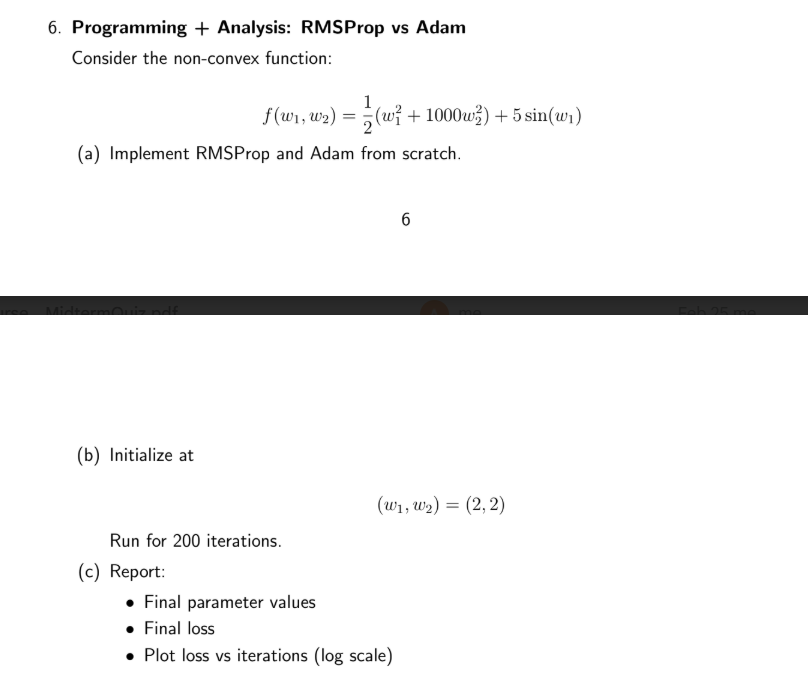

Final parameter values RMS Prop : [0.99858813 1.21160112]
Final loss : 738.690762367803
Final parameter values Adam : [1.7893865  1.80413754]
Final loss : 1633.9381004280322


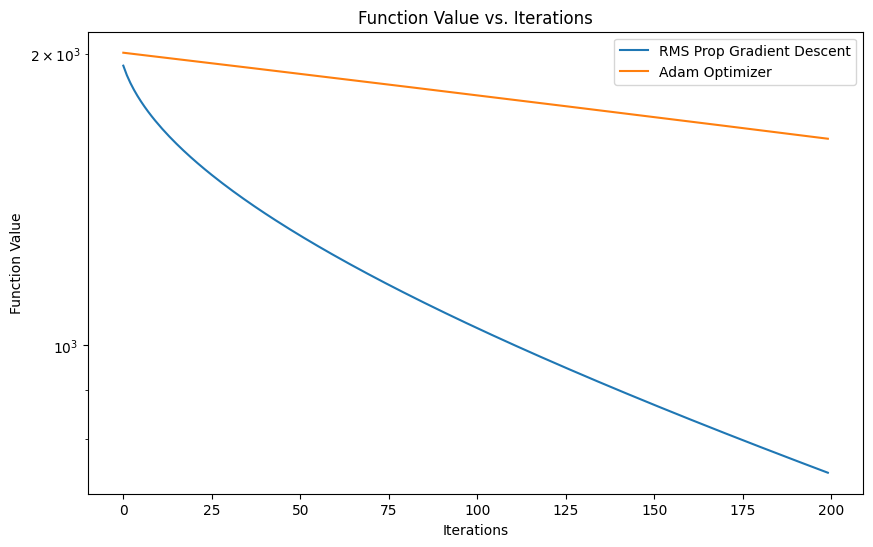

In [ ]:
#==============================================
# 1. function and graident
#==============================================

def q6_non_linear_function(w1,w2):
    return 0.5*(w1**2 + 1000*(w2**2)) + 5 * np.sin(w1)

def q6_non_linear_gradient(w1,w2):
    df_dxw1= 2*w1 + 5*np.cos(w1)
    df_dw2 = 1000*w2
    return np.array([df_dxw1,df_dw2])

#================================================
# 2. RMS Prop
#===============================================
def q6_rms_prop(w1,w2,learning_rate,iterations,beta1=0.9,beta2=0.999,epsilon=1e-8):
    w1 , w2 = w1 , w2
    v = np.zeros(2)
    fun_value = []

    for t in range(1,iterations+1):
        jacobian = q6_non_linear_gradient(w1,w2)
        v = beta2*v + (1-beta2)*(jacobian**2)
        w1 = w1 - learning_rate * (jacobian[0] / (np.sqrt(v[0]) + epsilon))
        w2 = w2 - learning_rate * (jacobian[1] / (np.sqrt(v[1]) + epsilon))
        fun_value.append(q6_non_linear_function(w1,w2))
    return np.array(fun_value),np.array([w1,w2])


#===================================================
# 3. Adam Optimizer
#===================================================
def q6_adam_optimizer(w1,w2,learning_rate,iterations,beta1=0.9,beta2=0.999,epsilon=1e-8):
    w1 , w2 = w1 , w2
    m = np.zeros(2)
    v = np.zeros(2)
    fun_value = []

    for t in range(1,iterations+1):
        jacobian = q6_non_linear_gradient(w1,w2)
        #moments
        m = beta1*m + (1-beta1)*jacobian
        v = beta2*v + (1-beta2)*(jacobian**2)
        #bias correction
        m_hat = m/(1-beta1**t)
        v_hat = v/(1-beta2**t)
        #parameter update
        w1 = w1 - learning_rate*(m_hat[0]/(np.sqrt(v_hat[0])+epsilon))
        w2 = w2 - learning_rate*(m_hat[1]/(np.sqrt(v_hat[1])+epsilon))
        fun_value.append(q6_non_linear_function(w1,w2))
    return np.array(fun_value),np.array([w1,w2])


#===============================================================
# 4. Run  + value vs. iterations Plot
#===============================================================
learning_rate = 0.001
iterations = 200
w1,w2 = 2, 2

r_fun_value , r_paramter = q6_rms_prop(w1,w2,learning_rate,iterations)
a_fun_value , a_paramter = q6_adam_optimizer(w1,w2,learning_rate,iterations)

print("=="*30)
print(f"Final parameter values RMS Prop : {r_paramter}")
print(f"Final loss : {r_fun_value[-1]}")
print(f"Final parameter values Adam : {a_paramter}")
print(f"Final loss : {a_fun_value[-1]}")

#plotting
plt.figure(figsize=(10,6))
plt.plot(range(200),r_fun_value,label="RMS Prop Gradient Descent")
plt.plot(range(200),a_fun_value,label="Adam Optimizer")
plt.yscale("log")
plt.title("Function Value vs. Iterations")
plt.xlabel("Iterations")
plt.ylabel("Function Value")
plt.legend()
plt.show()

## Question 8 :(Coding and Analysis) Empirically validate the need for specific weight initialization strategies.
----


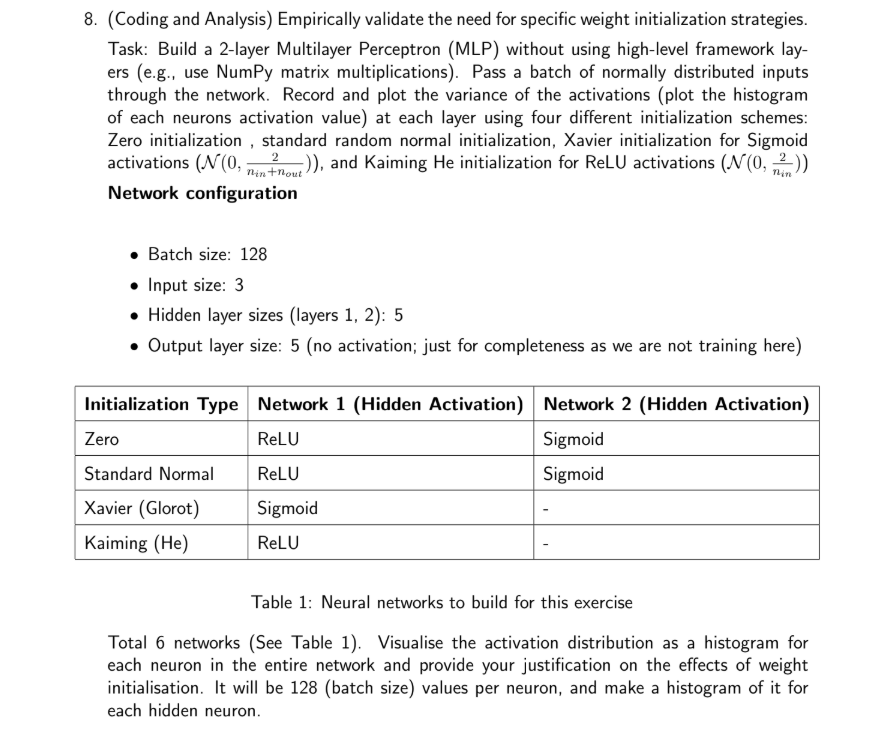


Zero Init + ReLU
Layer1 variance: 0.0
Layer2 variance: 0.0


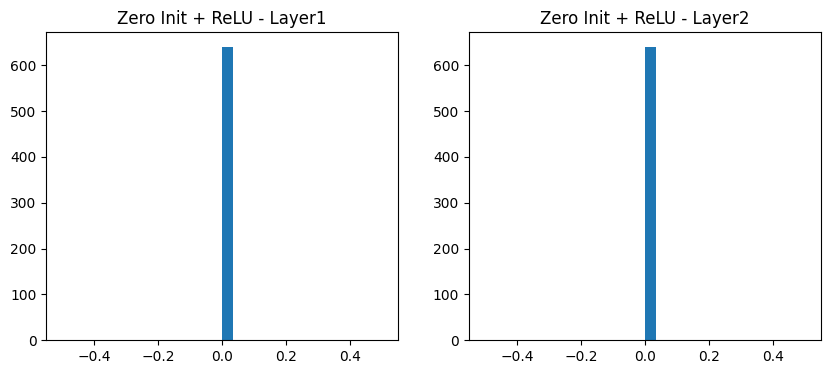


Normal Init + ReLU
Layer1 variance: 1.3066079553187833
Layer2 variance: 5.008015999045325


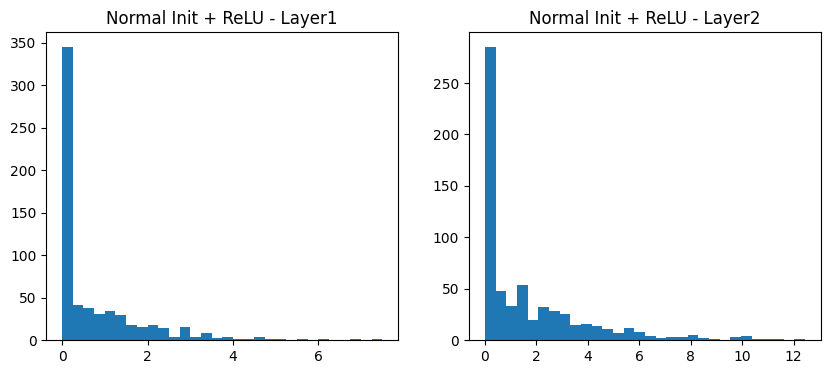


Normal Init + Sigmoid
Layer1 variance: 0.05983432672715984
Layer2 variance: 0.09995753098066626


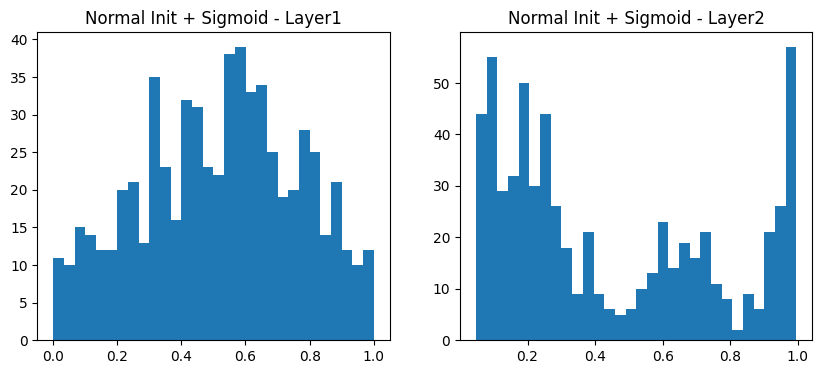


Xavier + Sigmoid
Layer1 variance: 0.01583709448286403
Layer2 variance: 0.01124596921597679


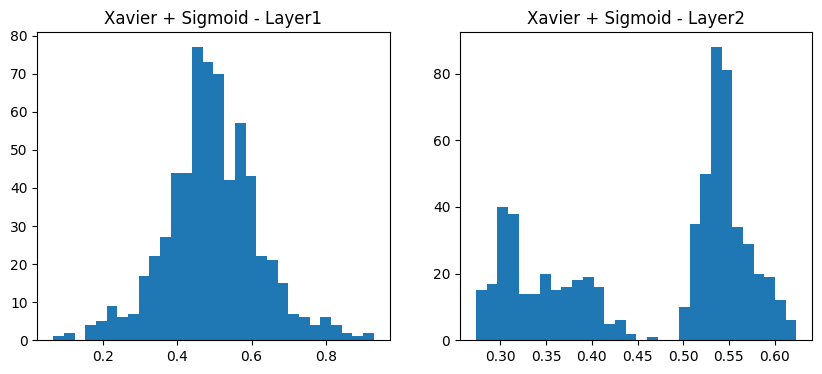


Kaiming + ReLU
Layer1 variance: 0.45148158035947683
Layer2 variance: 1.4430311543074303


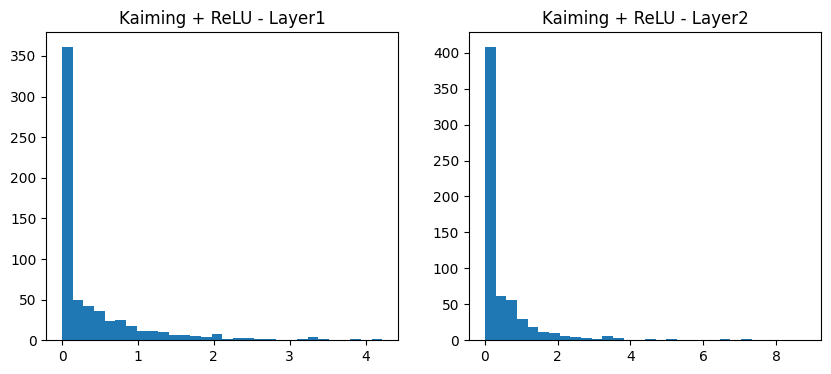

In [ ]:
#===================================================
# 1.Activation Functions
#===================================================
def q8_relu(x):
    return np.maximum(0, x)

def q8_sigmoid(x):
    return 1 / (1 + np.exp(-x))

#====================================================
# 2. Weight Intialization
#====================================================
def q8_init_weights(init_type, fan_in, fan_out):

    if init_type == "zero":
        return np.zeros((fan_in, fan_out))

    elif init_type == "normal":
        return np.random.randn(fan_in, fan_out)

    elif init_type == "xavier":
        return np.random.randn(fan_in, fan_out) * np.sqrt(1 / (fan_in + fan_out))

    elif init_type == "kaiming":
        return np.random.randn(fan_in, fan_out) * np.sqrt(2 / fan_in)

#================================================================
# 3. forward pass
#================================================================
def q8_forward_pass(X, W1, W2, W3, activation):

    Z1 = X @ W1
    A1 = activation(Z1)

    Z2 = A1 @ W2
    A2 = activation(Z2)

    Z3 = A2 @ W3  # output layer (no activation)

    return A1, A2, Z3
#=================================================================
# 4. Network Training
#=================================================================
def q8_network_training(init_type, activation_fn, title):

    W1 = q8_init_weights(init_type, 3, 5)
    W2 = q8_init_weights(init_type, 5, 5)
    W3 = q8_init_weights(init_type, 5, 5)

    A1, A2, _ = q8_forward_pass(X, W1, W2, W3, activation_fn)

    print(f"\n{title}")
    print("Layer1 variance:", np.var(A1))
    print("Layer2 variance:", np.var(A2))

    # Plot histogram
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(A1.flatten(), bins=30)
    plt.title(f"{title} - Layer1")

    plt.subplot(1,2,2)
    plt.hist(A2.flatten(), bins=30)
    plt.title(f"{title} - Layer2")

    plt.show()

#=========================================
# 5.inputs
#========================================
np.random.seed(42)
X = np.random.randn(128, 3)  # batch of inputs

#===========================================
# 6. Run + Analysis
#==========================================
# 1. Zero + ReLU
q8_network_training("zero", q8_relu, "Zero Init + ReLU")
# 2. Normal + ReLU
q8_network_training("normal", q8_relu, "Normal Init + ReLU")
# 3. Normal + Sigmoid
q8_network_training("normal", q8_sigmoid, "Normal Init + Sigmoid")
# 4. Xavier + Sigmoid
q8_network_training("xavier", q8_sigmoid, "Xavier + Sigmoid")
# 5. Kaiming + ReLU
q8_network_training("kaiming", q8_relu, "Kaiming + ReLU")

## Question 10 : Coding: RMSProp with ReLU Activation
----



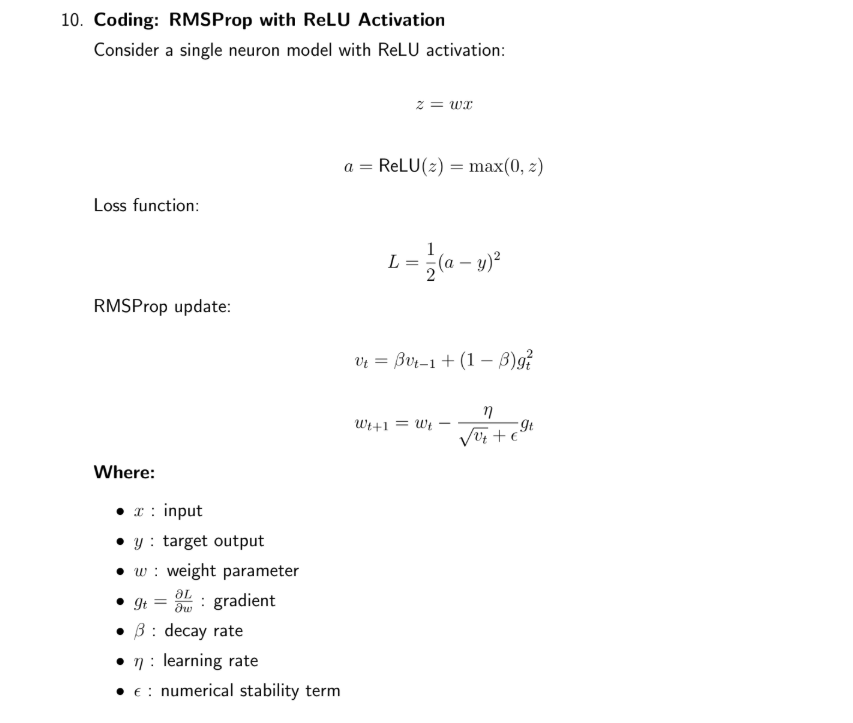

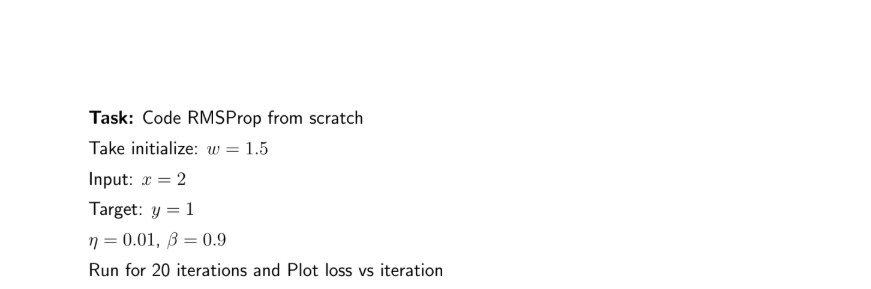

Final weight: 1.228163237031894
Final loss: 1.088990046933436


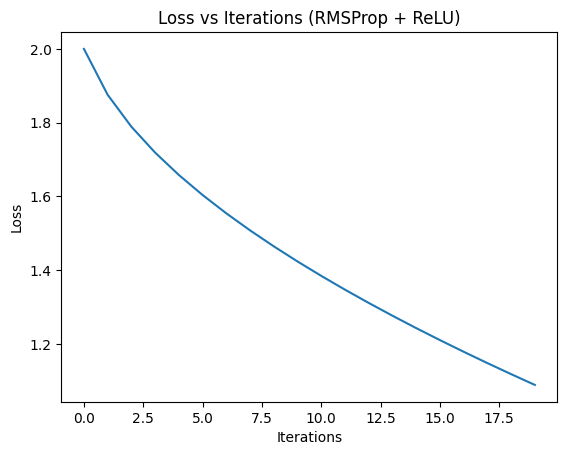

In [ ]:
# intial  values
w = 1.5
x = 2
y = 1

learning_rate = 0.01
beta = 0.9
epsilon = 1e-8

v = 0  # RMSProp accumulator
losses = []

for t in range(20):

    # Forward pass
    z = w * x
    a = max(0, z)

    loss = 0.5 * (a - y)**2
    losses.append(loss)

    # Backward pass (gradient)
    if z > 0:
        g = (a - y) * x
    else:
        g = 0

    # RMSProp update
    v = beta * v + (1 - beta) * (g**2)
    w = w - learning_rate * g / (np.sqrt(v) + epsilon)

print("Final weight:", w)
print("Final loss:", losses[-1])

#loss plot
plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations (RMSProp + ReLU)")
plt.show()

## Questions 12 :Coding: Optimization in a Non-Convex Loss
---



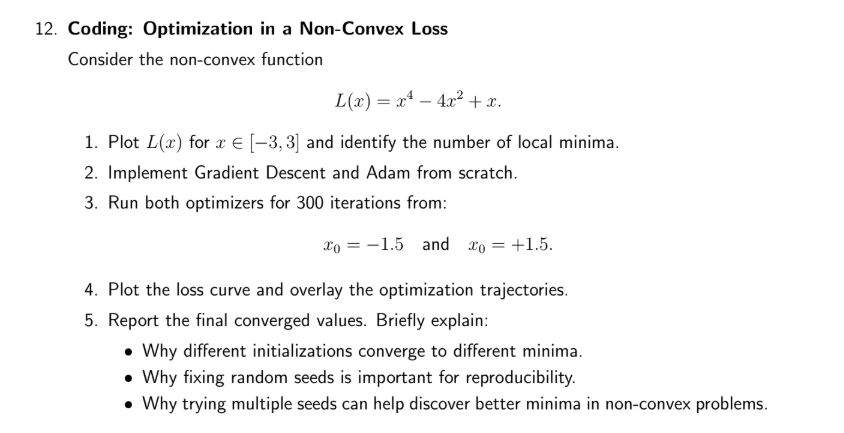

SGD final x: -1.4729976011140307, loss: -5.444192066610897
Adam final x: -1.4729976040863435, loss: -5.444192066610897
SGD final x: 1.3469974085277747, loss: -2.618555980765247
Adam final x: 1.346997400805748, loss: -2.6185559807652474


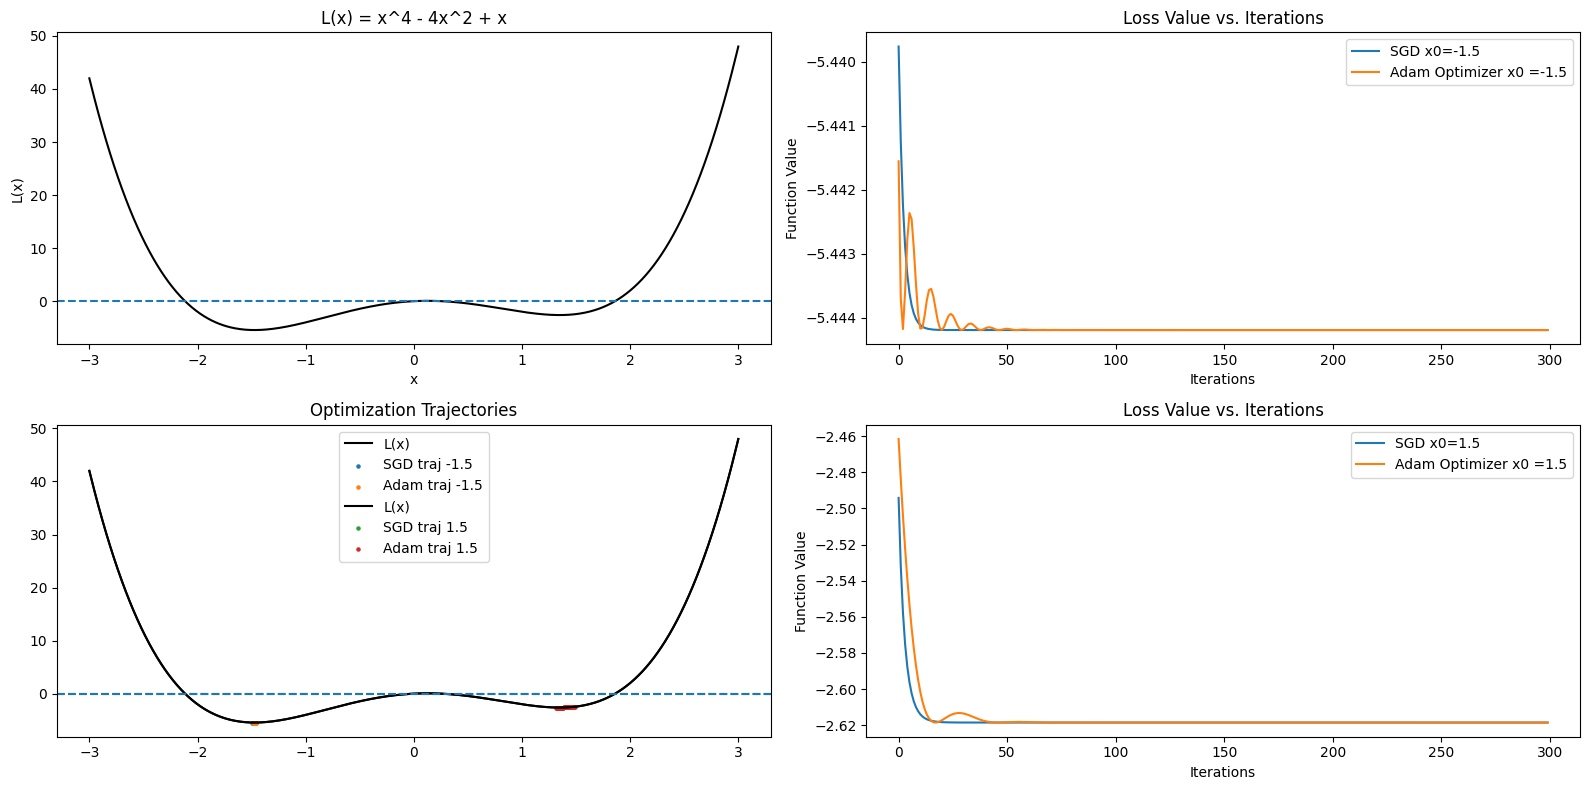

In [ ]:
#==============================================
# 1. function and graident
#==============================================

def q12_function(x):
    return x**4 - 4*(x**2) + x

def q12_gradient(x):
    df_dx = 4*(x**3) -8*x + 1
    return df_dx

#================================================
# 2. Gradient Descent (SGD)
#================================================
def q12_sgd_grad(x0,learning_rate,iterations):
    x  = x0
    fun_value = []
    trajectory = []
    for i in range(iterations):
        jacobian = q12_gradient(x)
        x = x - learning_rate*jacobian
        fun_value.append(q12_function(x))
        trajectory.append(x)
    return np.array(fun_value) , np.array(trajectory)

#===================================================
# 3. Adam Optimizer
#===================================================
def q12_adam_optimizer(x0,learning_rate,iterations,beta1=0.9,beta2=0.999,epsilon=1e-8):
    x = x0
    m,v = 0,0
    fun_value = []
    trajectory = []

    for t in range(1,iterations+1):
        jacobian = q12_gradient(x)
        #moments
        m = beta1*m + (1-beta1)*jacobian
        v = beta2*v + (1-beta2)*(jacobian**2)
        #bias correction
        m_hat = m/(1-beta1**t)
        v_hat = v/(1-beta2**t)
        #parameter update
        x = x - learning_rate*(m_hat/(np.sqrt(v_hat)+epsilon))
        fun_value.append(q12_function(x))
        trajectory.append(x)
    return np.array(fun_value),np.array(trajectory)

#=================================================================
# 4.Plot the function
#=================================================================
fig,axes = plt.subplots(2,2,figsize=(16,8))
x_vals = np.linspace(-3, 3, 500)
y_vals = q12_function(x_vals)

axes[0,0].plot(x_vals, y_vals, color='black', label="L(x)")
axes[0,0].axhline(0, linestyle='--')
axes[0,0].set_title("L(x) = x^4 - 4x^2 + x")
axes[0,0].set_xlabel("x")
axes[0,0].set_ylabel("L(x)")

#===============================================================
# 5. Run  + value vs. iterations Plot
#===============================================================
learning_rate = 0.01
iterations = 300
x_val = [-1.5, 1.5]
i=0
for x0 in x_val:
    v_fun_value , v_traj = q12_sgd_grad(x0,learning_rate,iterations)
    a_fun_value , a_traj = q12_adam_optimizer(x0,learning_rate,iterations)
    #plotting
    axes[i,1].plot(range(300),v_fun_value,label=f"SGD x0={x0}")
    axes[i,1].plot(range(300),a_fun_value,label=f"Adam Optimizer x0 ={x0}")
    axes[i,1].set_title("Loss Value vs. Iterations")
    axes[i,1].set_xlabel("Iterations")
    axes[i,1].set_ylabel("Function Value")
    axes[i,1].legend()

    print(f"SGD final x: {v_traj[-1]}, loss: {v_fun_value[-1]}")
    print(f"Adam final x: {a_traj[-1]}, loss: {a_fun_value[-1]}")


    #=================================================================
    # 6. Overlay Trajectories + Trajectory
    #=================================================================
    axes[1,0].plot(x_vals, y_vals, color='black', label="L(x)")
    axes[1,0].axhline(0, linestyle='--')
    axes[1,0].scatter(v_traj, q12_function(v_traj), s=5, label=f"SGD traj {x0}")
    axes[1,0].scatter(a_traj, q12_function(a_traj), s=5, label=f"Adam traj {x0}")
    i= i+1

axes[1,0].set_title("Optimization Trajectories")
axes[1,0].legend()
plt.tight_layout()


In [ ]:
obserbations = f'''
1.The optimization algorithm (SGD/Adam) follows the local gradient (slope).Starting at =−1.5 → converges to left minimum Starting at =+1.5 → converges to right minimum.
2.Fixing seeds ensures consistent and reproducible experiments, which is critical for debugging and comparison.
3.Multiple seeds = better exploration of non-convex landscape
'''
print(obserbations)


1.The optimization algorithm (SGD/Adam) follows the local gradient (slope).Starting at =−1.5 → converges to left minimum Starting at =+1.5 → converges to right minimum.
2.Fixing seeds ensures consistent and reproducible experiments, which is critical for debugging and comparison.
3.Multiple seeds = better exploration of non-convex landscape



## Question 14 : Programming : Comparing SGD and Momentum
---


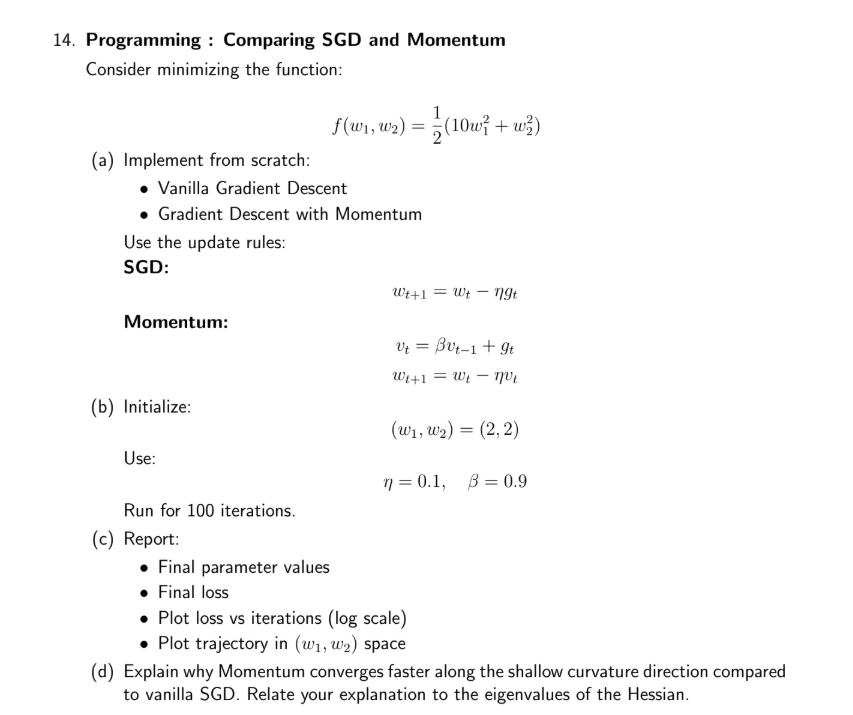

Final parameter values Vanilla SGD : [0.00000000e+00 5.31227978e-05]
Final loss : 1.4110158217310646e-09
Final parameter values momentum : [0.00270009 0.00747747]
Final loss : 6.440874502832226e-05


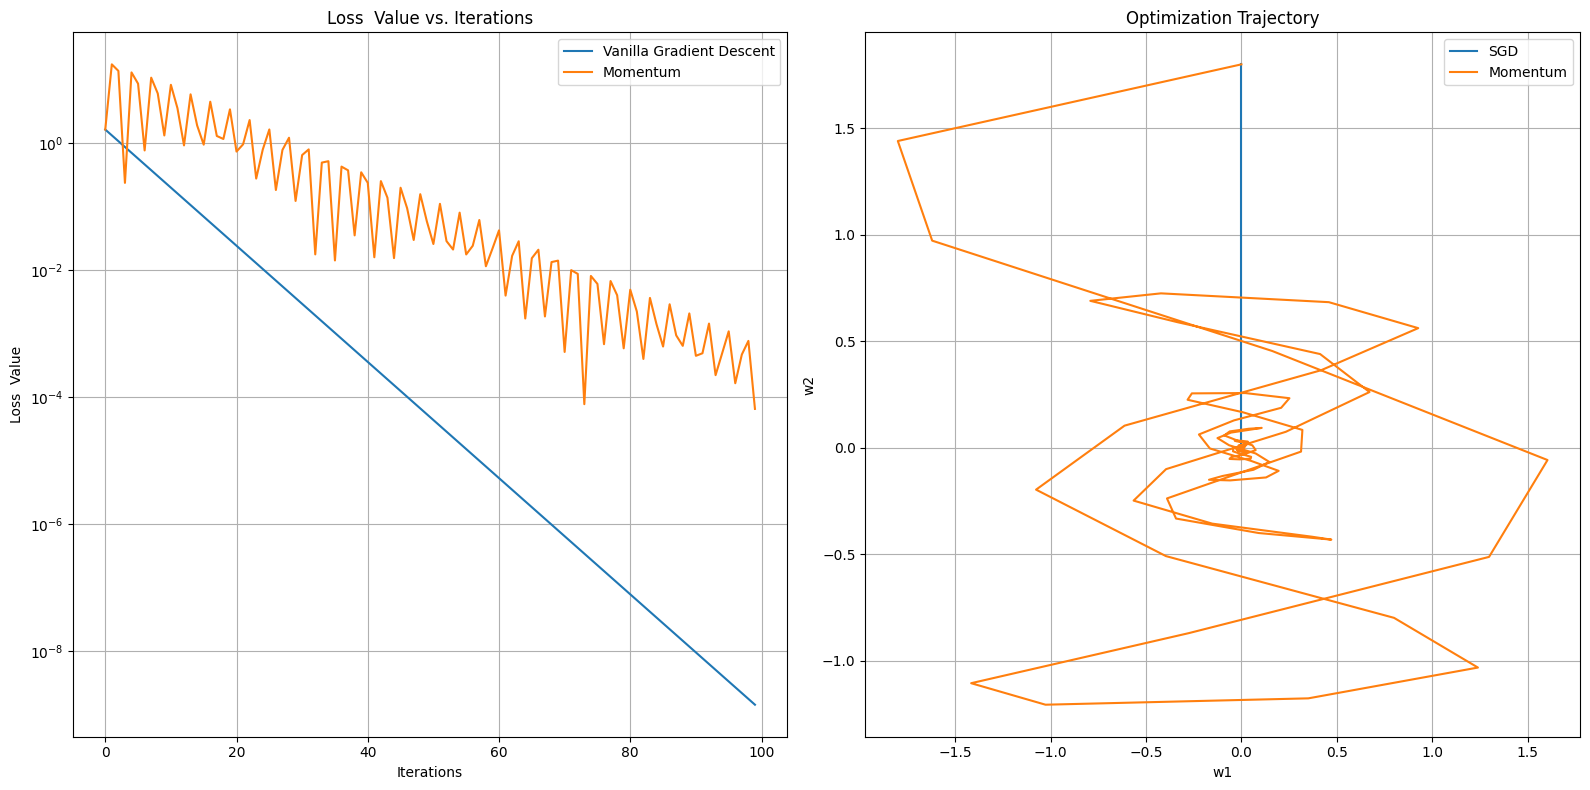

In [ ]:
#==============================================
# 1. function and graident
#==============================================

def q14_non_linear_function(w1,w2):
    return 0.5*(10*(w1**2) + w2**2)

def q14_non_linear_gradient(w1,w2):
    df_dxw1= 10*w1
    df_dw2 = w2
    return np.array([df_dxw1,df_dw2])

#================================================
# 2. Vanilla Gradient Descent (SGD)
#================================================
def q14_vanilla_grad(w1,w2,learning_rate,iterations):
    w1 , w2 = w1 , w2
    fun_value = []
    trajectory = []
    for i in range(iterations):
        jacobian = q14_non_linear_gradient(w1,w2)
        w1 = w1 - learning_rate*jacobian[0]
        w2 = w2 - learning_rate*jacobian[1]
        fun_value.append(q14_non_linear_function(w1,w2))
        trajectory.append((w1,w2))
    return np.array(fun_value) , np.array(trajectory)


#===================================================
# 3. Momentum Grad
#===================================================
def q14_momentum_grad(w1,w2,learning_rate,iterations,beta=0.9):
    w1 , w2 = w1 , w2
    v = np.zeros(2)
    fun_value = []
    trajectory = []
    for t in range(1,iterations+1):
        jacobian = q14_non_linear_gradient(w1,w2)
        #moments
        v = beta*v + jacobian
        #parameter update
        w1 = w1 - learning_rate*(v[0])
        w2 = w2 - learning_rate*(v[1])
        fun_value.append(q14_non_linear_function(w1,w2))
        trajectory.append((w1,w2))
    return np.array(fun_value),np.array(trajectory)


#===============================================================
# 4. Run  + value vs. iterations Plot
#===============================================================
learning_rate = 0.1
iterations = 100
w1,w2 = 2, 2

v_fun_value , v_traj = q14_vanilla_grad(w1,w2,learning_rate,iterations)
m_fun_value , m_traj = q14_momentum_grad(w1,w2,learning_rate,iterations)

print("=="*30)
print(f"Final parameter values Vanilla SGD : {v_traj[-1]}")
print(f"Final loss : {v_fun_value[-1]}")
print(f"Final parameter values momentum : {m_traj[-1]}")
print(f"Final loss : {m_fun_value[-1]}")

#plotting
fig,axes = plt.subplots(1,2,figsize=(16,8))
axes[0].plot(range(100),v_fun_value,label="Vanilla Gradient Descent")
axes[0].plot(range(100),m_fun_value,label="Momentum")
axes[0].set_yscale("log")
axes[0].set_title("Loss  Value vs. Iterations")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Loss  Value")
axes[0].legend()
axes[0].grid()



axes[1].plot(v_traj[:,0], v_traj[:,1], label="SGD")
axes[1].plot(m_traj[:,0], m_traj[:,1], label="Momentum")
axes[1].set_xlabel("w1")
axes[1].set_ylabel("w2")
axes[1].set_title("Optimization Trajectory")
axes[1].legend()
axes[1].grid()

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
oberbations = '''
1.Hessian = np.array([[10,0],
                    [0,1]])
1.SGD Behavior : Uses same learning rate in all directions
Causes:slow movement in shallow direction , stable but not accelerated updates
2.Momentum Behaviour : Momentum Behavior ,Accumulates gradients - accelerates convergence , In steep direction:can overshoot if learning rate is high
'''
print(oberbations)


1.Hessian = np.array([[10,0],
                    [0,1]])
1.SGD Behavior : Uses same learning rate in all directions
Causes:slow movement in shallow direction , stable but not accelerated updates
2.Momentum Behaviour : Momentum Behavior ,Accumulates gradients - accelerates convergence , In steep direction:can overshoot if learning rate is high



## Question 15. Programming: Gradient Descent vs Newton’s Method
---


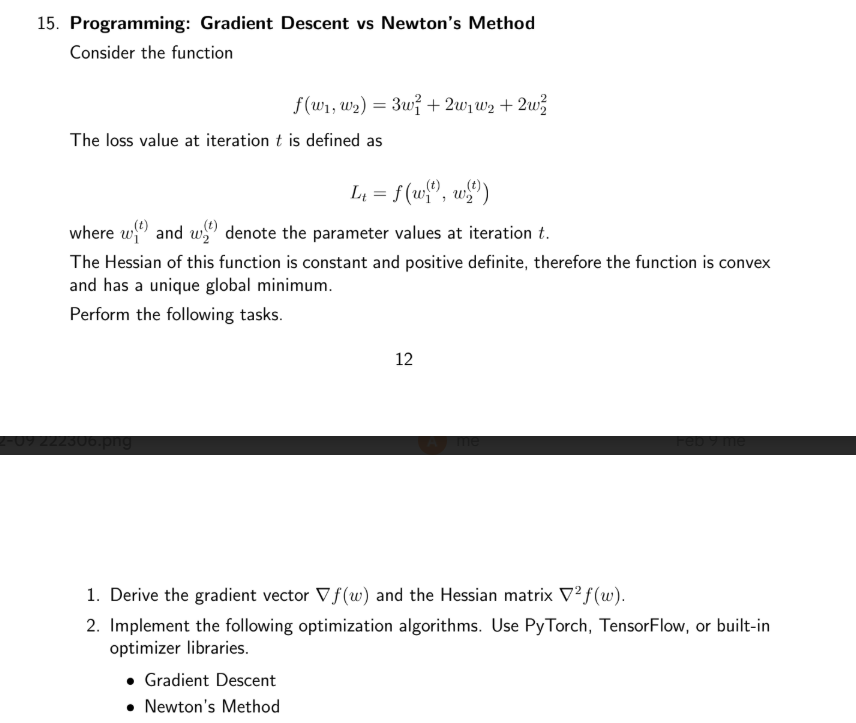

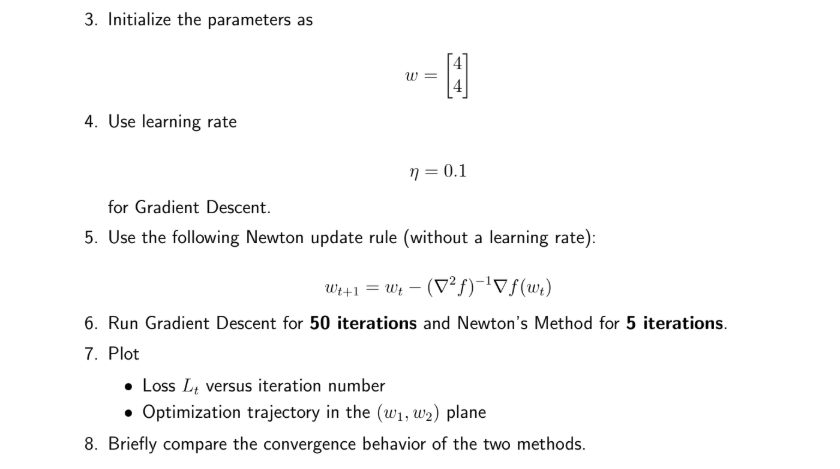

GD final: [-6.4525523e-08  1.0440448e-07] loss: 3.9758286588106526e-14
Newton final: [0. 0.] loss: 0.0


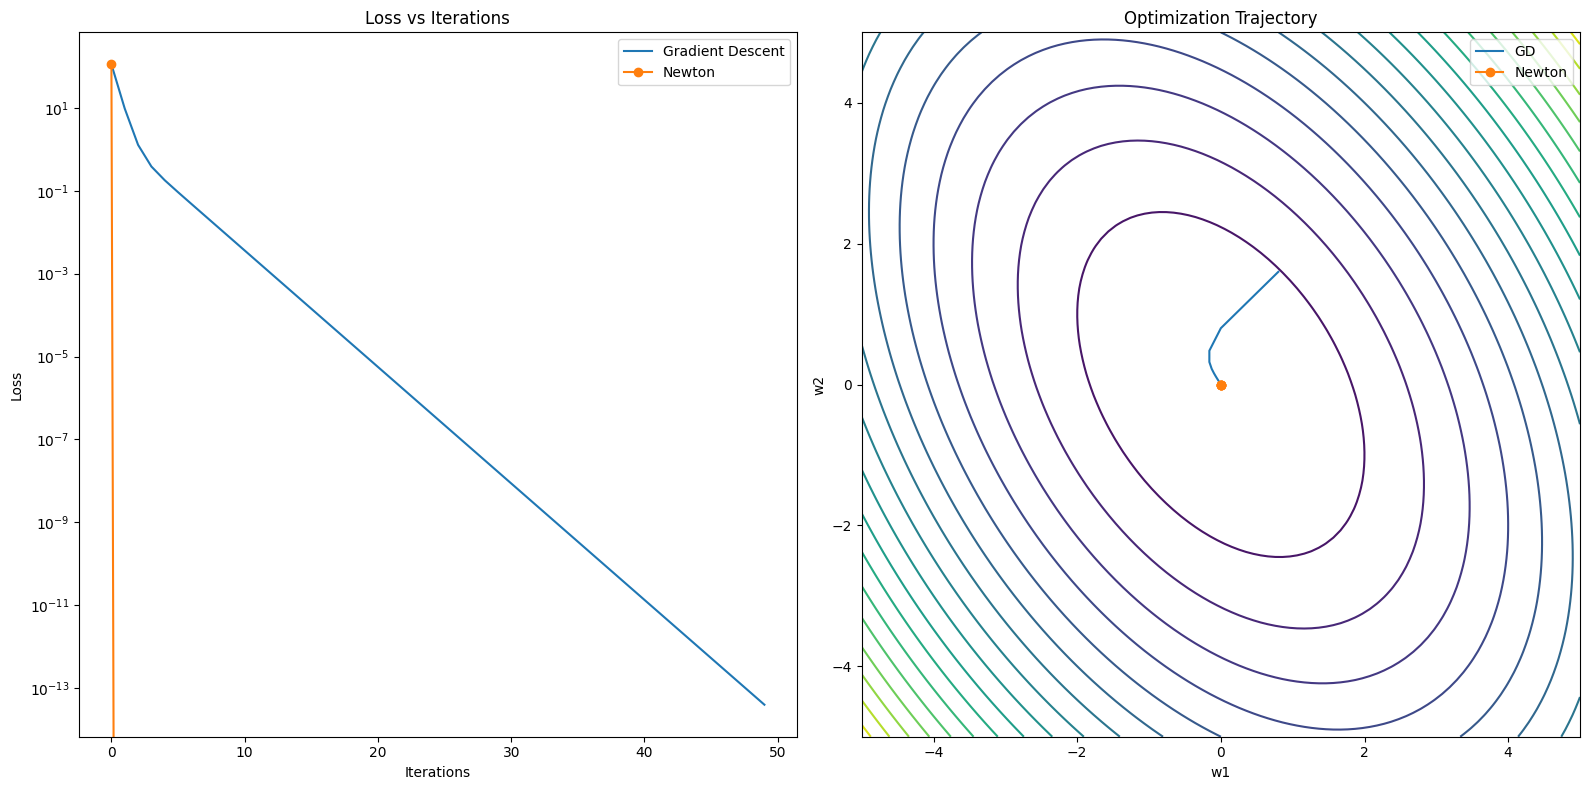

In [ ]:
#==============================================
# 1. function + Hessian
#==============================================
def q15_non_linear_function(w):
    w1, w2 = w
    return 3*w1**2 + 2*w1*w2 + 2*w2**2

def q15_hessian():
    return torch.tensor([[6.0, 2.0],
                         [2.0, 4.0]])

#================================================
# 2.  Gradient Descent (SGD)
#================================================
def q15_gradient_descent(w0, lr, iterations=50):
    w = torch.tensor(w0, dtype=torch.float32, requires_grad=True)

    traj = []
    loss = []

    for _ in range(iterations):
        L = q15_non_linear_function(w)
        L.backward()

        with torch.no_grad():
            w -= lr * w.grad

        w.grad.zero_()

        traj.append(w.detach().numpy().copy())
        loss.append(L.item())

    return loss, traj
#================================================
# 3. Newton Method
#================================================
def q15_newton_method(w0, iterations=5):
    w = torch.tensor(w0, dtype=torch.float32)

    H_inv = torch.inverse(q15_hessian())

    traj = []
    loss = []

    for _ in range(iterations):
        w.requires_grad_(True)

        L = q15_non_linear_function(w)
        L.backward()

        g = w.grad

        with torch.no_grad():
            w = w - H_inv @ g

        traj.append(w.detach().numpy().copy())
        loss.append(L.item())

    return loss, traj

#===============================================================
# 4. Run  + value vs. iterations Plot
#===============================================================
w0 = [4.0, 4.0]

gd_loss, gd_traj = q15_gradient_descent(w0, lr=0.1, iterations=50)
nt_loss, nt_traj = q15_newton_method(w0, iterations=5)

print("=="*30)
print("GD final:", gd_traj[-1], "loss:", gd_loss[-1])
print("Newton final:", nt_traj[-1], "loss:", nt_loss[-1])


# Loss vs Iterations plot
fig,axes = plt.subplots(1,2,figsize=(16,8))
axes[0].plot(gd_loss, label="Gradient Descent")
axes[0].plot(range(0,50,10), nt_loss, 'o-', label="Newton")
axes[0].set_yscale("log")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss vs Iterations")
axes[0].legend()


# Optimization trajectory
gd_traj = np.array(gd_traj)
nt_traj = np.array(nt_traj)

x = np.linspace(-5,5,100)
y = np.linspace(-5,5,100)
X, Y = np.meshgrid(x, y)
Z = 3*X**2 + 2*X*Y + 2*Y**2

axes[1].contour(X, Y, Z, levels=20)

axes[1].plot(gd_traj[:,0], gd_traj[:,1], label="GD")
axes[1].plot(nt_traj[:,0], nt_traj[:,1], 'o-', label="Newton")

axes[1].set_xlabel("w1")
axes[1].set_ylabel("w2")
axes[1].set_title("Optimization Trajectory")
axes[1].legend()

plt.tight_layout()

In [ ]:
obserbations = '''
1. Netwon method generally converges faster in this case it has converges in just 10 iterations.
2. Gradient descent require more number of iterations to converge.
'''
print(obserbations)


1. Netwon method generally converges faster in this case it has converges in just 10 iterations.
2. Gradient descent require more number of iterations to converge.

